In [ ]:
# tiff


# /home/alex/repos/monorepo/external_files/data/LWIR/captures2/cap100raw/...


# Images:
# Boson_320_agc_0.tiff
# ...


# 1. read images into TileDB
# 2. run fft
# 3. run binarization
# 4. show results



In [ ]:


%load_ext autoreload
%autoreload 2

import os

import numpy as np
from PIL import Image

import cv2
from scipy import ndimage

import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal
from scipy import signal
import numpy as np
from scipy.stats import poisson

from dataengine.visualizers.video_segment import VisTool

import scipy

from dataengine.buffer import DataBuffer

from skimage.color import rgb2gray
# from skimage.data import stereo_motorcycle, vortex
from skimage.transform import warp
from skimage.registration import optical_flow_tvl1, optical_flow_ilk



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


pix:  (512, 640)


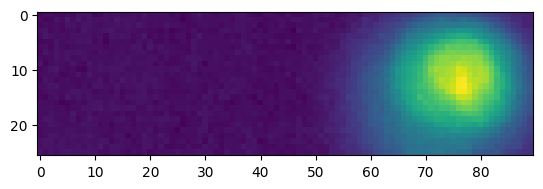

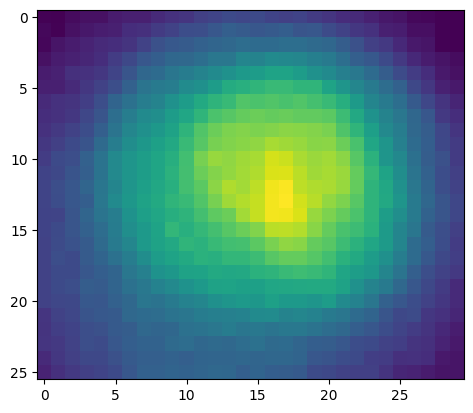

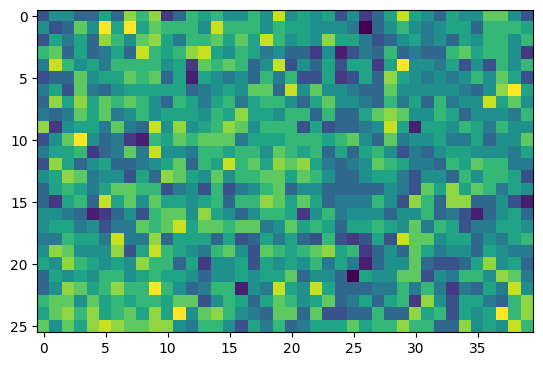

background: max, min, var, mean, std:  21 9 4.59282451923077 15.5375 2.143087613521848
beacon: max, min, var, mean, std:  200 26 1741.2488888888888 97.53333333333333 41.72827445376682


In [16]:

img = 'lwir/1707777322740_Boson_640_agc_0.tiff'
img = Image.open(img)

pix = np.array(img)

print("pix: ", pix.shape)

# Beacon next to nothing
window = pix[230:256, 250:340]
vis_tool.show(window)

# Bright spot (right side)
beacon = pix[230:256, 310:340]
vis_tool.show(beacon)

# Dark area (left side)
dark = pix[230:256, 250:290]
vis_tool.show(dark)

# Dark background image
var = np.var(dark)
mean = np.mean(dark)
std = np.std(dark)
print("background: max, min, var, mean, std: ", dark.max(), dark.min(), var, mean, std)


# Beacon (foreground
var_beacon = np.var(beacon)
mean_beacon = np.mean(beacon)
std_beacon = np.std(beacon)
print("beacon: max, min, var, mean, std: ", beacon.max(), beacon.min(), var_beacon, mean_beacon, std_beacon)

